# leafwaxtools Tutorial: Chain API class

Import the leafwaxtools Chain module/class and other necessary packages for this tutorial. It's recommended to use the leafwaxtools conda environment (environment.yml) which contains all of the packages you'll need for this notebook.

In [1]:
from leafwaxtools import Chain

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Leaf Wax Data

First, we'll need to prepare some leaf wax carbon chain-length distribution data to use with the leafwaxtools Chain class. For this tutorial, we'll use this dataset (https://doi.org/10.25921/r1dc-8930) from Thomas et al. (2023). It contains leaf wax *n*-alkanoic acid data and branched glycerol dialkyl glycerol tetraether (brGDGT) data from Early Holocene lake sediment samples from Lake CF8, Baffin Island, Nunavut, Canada (70.56 N, 68.95 W). In this dataset, some samples (rows) do not contain any leaf wax chain-length data (expressed as "NaN"), so we remove them after importing the original .csv file.

Thomas, E. K., Cluett, A. A., Erb, M. P., McKay, N. P., Briner, J. P., Castañeda, I. S., ... & Salacup, J. (2023). Early Holocene Laurentide ice sheet retreat influenced summer atmospheric circulation in Baffin Bay. Geophysical Research Letters, 50(13), e2023GL103428. https://doi.org/10.1029/2023GL103428

In [2]:
cf8_data_df = pd.read_csv(r'../leafwaxtools/data/Thomas_CF8_2023.csv')

cf8_data_df.dropna(
    subset=[
        'peakAreaC20FattyAcidMethylEster',
        'peakAreaC21FattyAcidMethylEster',
        'peakAreaC22FattyAcidMethylEster',
        'peakAreaC23FattyAcidMethylEster',
        'peakAreaC24FattyAcidMethylEster',
        'peakAreaC25FattyAcidMethylEster',
        'peakAreaC26FattyAcidMethylEster',
        'peakAreaC27FattyAcidMethylEster',
        'peakAreaC28FattyAcidMethylEster',
        'peakAreaC29FattyAcidMethylEster',
        'peakAreaC30FattyAcidMethylEster',
        'peakAreaC31FattyAcidMethylEster',
        'peakAreaC32FattyAcidMethylEster',
    ], inplace=True
)
cf8_data_df.reset_index(drop=True, inplace=True)

cf8_data_df



,CoreName,MidpointDepth,TopDepth,Thickness,SamplingID,UBlabID,SamplingNotesAboutSedimentology,AquaticMossMacrofossilAbundance,MassDrySediment,MassTotalLipidExtract,...,FAbrGDGTIIa',FAbrGDGTIIb,FAbrGDGTIIb',FAbrGDGTIIc,FAbrGDGTIIc',FAbrGDGTIa,FAbrGDGTIb,FAbrGDGTIc,ZhaoIWT,ageMedian
0,07CF8L4,0.25,0.0,0.5,EKT249,EKT249,no large aquatic moss macrofossils (none even ...,0,1.042,4.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7522.741
1,07CF8L4,0.75,0.5,0.5,EKT248,EKT248,no large aquatic moss macrofossils (none even ...,0,0.965,3.83,...,0.062,0.034,0.005,0.001,0.0,0.138,0.022,0.001,8.189462,7545.194
2,07CF8L4,1.25,1.0,0.5,EKT247,EKT247,no large aquatic moss macrofossils (none even ...,0,0.927,3.30,...,0.065,0.033,0.004,0.001,0.0,0.137,0.021,0.001,8.044775,7564.971
3,07CF8L4,1.75,1.5,0.5,EKT246,EKT246,no large aquatic moss macrofossils (none even ...,0,0.902,3.10,...,0.060,0.033,0.004,0.001,0.0,0.141,0.023,0.001,8.325403,7594.084
4,07CF8L4,2.25,2.0,0.5,EKT245,EKT245,no large aquatic moss macrofossils (none even ...,0,0.955,3.31,...,0.069,0.029,0.005,0.001,0.0,0.145,0.025,0.001,8.853391,7621.021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,07CF8L4,68.25,68.0,0.5,EKT113,EKT113,lots of aquatic moss macrofossils (hard to sam...,6,0.790,NaN,...,0.053,0.007,0.000,0.000,0.0,0.110,0.006,0.000,5.267715,10837.010
91,07CF8L4,77.25,77.0,0.5,EKT095,EKT095,aquatic moss macrofossils,2,1.817,NaN,...,0.037,0.006,0.000,0.001,0.0,0.119,0.004,0.000,5.504847,11834.990
92,07CF8L4,77.75,77.5,0.5,EKT094,EKT094,aquatic moss macrofossils,2,1.167,NaN,...,0.039,0.005,0.000,0.000,0.0,0.111,0.003,0.000,5.064226,11894.530
93,07CF8L4,78.25,78.0,0.5,EKT093,EKT093,aquatic moss macrofossils,2,1.149,NaN,...,0.046,0.003,0.000,0.000,0.0,0.117,0.002,0.000,5.330160,11959.460


## Preparing Leaf Wax Data

The functions in the leafwaxtools Chain class only require the chain-length data itself, and assume that it is organized where each row is a sample and each column is a carbon chain-length. Here, we isolate the chain-length data from the full dataset (with metadata and beGDGTs) to use with leafwaxtools.

Some functions in the Chain class (i.e., acl, cpi, pca) require the user to provide information about the carbon chain-length numbers of each data column. Here, we define a quick function, get_chain_lengths(), to extract the carbon chain-length number from the DataFrame column names. Users can also just provide a list when calling the function (i.e. chain_lengths=[22,24,26,28]).

In [3]:
# All n-alkanoic acid carbon chain-lengths
cf8_nacid_chain_df = cf8_data_df[
    [
        'peakAreaC20FattyAcidMethylEster',
        'peakAreaC21FattyAcidMethylEster',
        'peakAreaC22FattyAcidMethylEster',
        'peakAreaC23FattyAcidMethylEster',
        'peakAreaC24FattyAcidMethylEster',
        'peakAreaC25FattyAcidMethylEster',
        'peakAreaC26FattyAcidMethylEster',
        'peakAreaC27FattyAcidMethylEster',
        'peakAreaC28FattyAcidMethylEster',
        'peakAreaC29FattyAcidMethylEster',
        'peakAreaC30FattyAcidMethylEster',
        'peakAreaC31FattyAcidMethylEster',
        'peakAreaC32FattyAcidMethylEster',
    ]
]

# Only even-chain n-alkanoic acid carbon chain-lengths
cf8_nacid_evenchain_df = cf8_nacid_chain_df[
    [
        'peakAreaC20FattyAcidMethylEster',
        'peakAreaC22FattyAcidMethylEster',
        'peakAreaC24FattyAcidMethylEster',
        'peakAreaC26FattyAcidMethylEster',
        'peakAreaC28FattyAcidMethylEster',
        'peakAreaC30FattyAcidMethylEster',
        'peakAreaC32FattyAcidMethylEster',
    ]
]

def get_chain_lengths(df_columns):
    chain_lengths_num = [None] * len(df_columns)
    chain_lengths_str = [None] * len(df_columns)
    for i in range(len(df_columns)):
        column_name = df_columns[i]
        chain_lengths_num[i] = int(column_name[9:11])
        chain_lengths_str[i] = "C" + str(chain_lengths_num[i])

    return chain_lengths_num, chain_lengths_str


cf8_chain_lengths, cf8_chain_lengths_str = get_chain_lengths(cf8_nacid_chain_df.columns)
cf8_evenchain_lengths, cf8_evenchain_lengths_str = get_chain_lengths(cf8_nacid_evenchain_df.columns)

print(cf8_chain_lengths)
print(cf8_chain_lengths_str)
print(cf8_evenchain_lengths)
print(cf8_evenchain_lengths_str)


[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
['C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31', 'C32']
[20, 22, 24, 26, 28, 30, 32]
['C20', 'C22', 'C24', 'C26', 'C28', 'C30', 'C32']


## Total Concentration: Chain.total_conc()

This function calculates the total leaf wax concentration of each sample (row). In this dataset, chain-length abundances are reported as chromatograph peak areas (pA*min).

(0.0, 400.0)

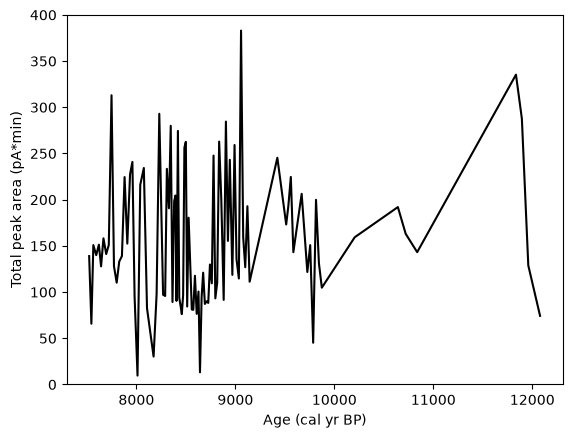

In [4]:
cf8_nacid_chain_total_conc = Chain(cf8_nacid_chain_df).total_conc()
cf8_nacid_chain_total_logconc = Chain(cf8_nacid_chain_df).total_conc(calculate_log=True)


fig, ax = plt.subplots()
ax.plot(cf8_data_df.ageMedian, cf8_nacid_chain_total_conc, color='black')
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Total peak area (pA*min)")
ax.set_ylim([0,400])

## Chain-Length Relative Abundance: Chain.relative_abd()

This function calculates the relative abundance (from 0 to 1) of each leaf wax chain-length. By setting calculate_percent=True, these values will be reported as percent abundances (0 to 100%) instead.

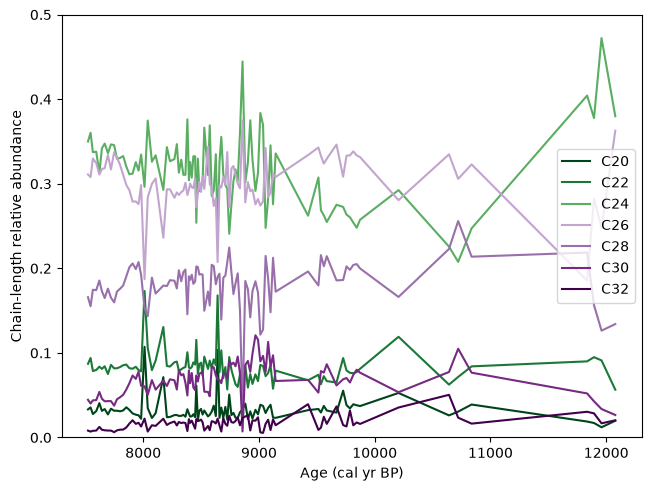

In [11]:
cf8_nacid_chain_relative_abd = Chain(cf8_nacid_evenchain_df).relative_abd()
cf8_nacid_chain_percent_abd = Chain(cf8_nacid_evenchain_df).relative_abd(calculate_percent=True)


colors = [
    '#00441b',
    '#1b7837',
    '#5aae61',
    '#c2a5cf',
    '#9970ab',
    '#762a83',
    '#40004b'
]

fig, ax = plt.subplots(layout='constrained')
for i in range(len(colors)):
    ax.plot(cf8_data_df.ageMedian, cf8_nacid_chain_relative_abd[:,i], color=colors[i], zorder=i, label=cf8_evenchain_lengths_str[i])
ax.set_ylim([0,0.5])
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Chain-length relative abundance")
ax.legend()

## Average Chain-Length: Chain.acl()

(24.5, 26.5)

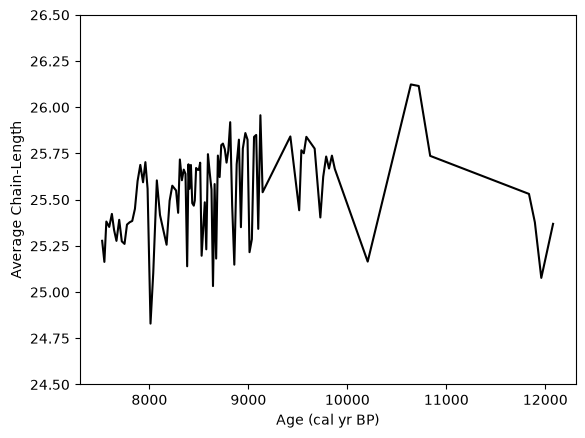

In [6]:
cf8_nacid_chain_acl = Chain(cf8_nacid_chain_df).acl(chain_lengths=cf8_chain_lengths)


fig, ax = plt.subplots()
ax.plot(cf8_data_df.ageMedian, cf8_nacid_chain_acl, color='black')
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Average Chain-Length")
ax.set_ylim([24.5,26.5])

## Carbon Preference Index: Chain.cpi()

(2.0, 10.0)

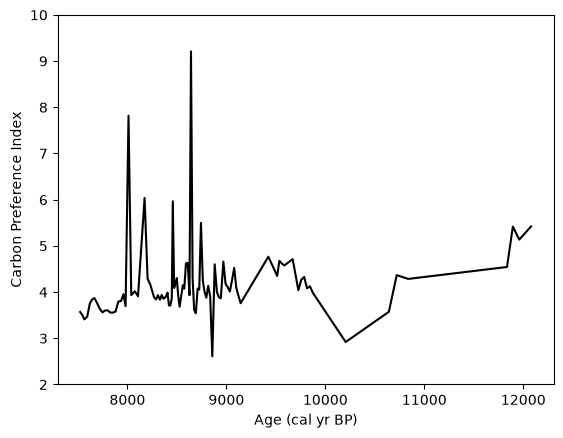

In [7]:
cf8_nacid_chain_cpi = Chain(cf8_nacid_chain_df).cpi(chain_lengths=cf8_chain_lengths)


fig, ax = plt.subplots()
ax.plot(cf8_data_df.ageMedian, cf8_nacid_chain_cpi, color='black')
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Carbon Preference Index")
ax.set_ylim([2,10])

## Correlation Matrices: Chain.correlation_rvals() & Chain.correlation_pvals()

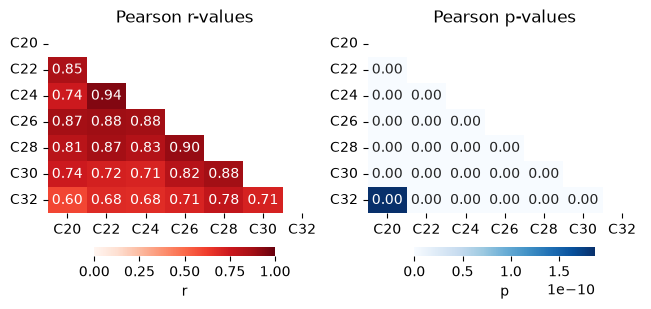

In [8]:
cf8_nacid_chain_correlation_rvals = Chain(cf8_nacid_evenchain_df).correlation_rvals()
cf8_nacid_chain_correlation_pvals = Chain(cf8_nacid_evenchain_df).correlation_pvals()


fig, axs = plt.subplots(2,2,layout='constrained')

corr_mask = np.triu(np.ones_like(cf8_nacid_chain_correlation_rvals, dtype=bool))

ax = axs[0,0]
ax.set_title("Pearson r-values")
sns.heatmap(
    ax=ax, data=cf8_nacid_chain_correlation_rvals,
    cmap='Reds', mask=corr_mask, annot=True, fmt='.2f', vmin=0, vmax=1,
    linewidths=0, linecolor='black', clip_on=False,
    cbar=True, cbar_kws={'label': "r", 'shrink': 0.66, 'location': 'bottom'},
    xticklabels=cf8_evenchain_lengths_str,
    yticklabels=cf8_evenchain_lengths_str
)

ax = axs[0,1]
ax.set_title("Pearson p-values")
sns.heatmap(
    ax=ax, data=cf8_nacid_chain_correlation_pvals,
    cmap='Blues', mask=corr_mask, annot=True, fmt='.2f',
    linewidths=0, linecolor='black', clip_on=False,
    cbar=True, cbar_kws={'label': "p", 'shrink': 0.66, 'location': 'bottom'},
    xticklabels=cf8_evenchain_lengths_str,
    yticklabels=cf8_evenchain_lengths_str
)

fig.delaxes(axs[1,0])
fig.delaxes(axs[1,1])



## Principal Component Analysis: Chain.pca()

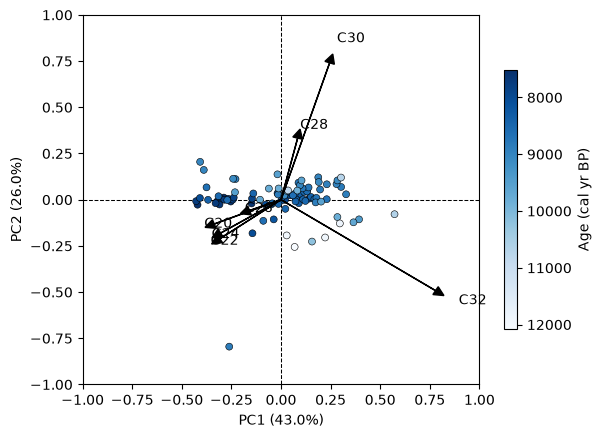

In [9]:
cf8_nacid_evenchain_pca = Chain(cf8_nacid_evenchain_df).pca(chain_lengths=cf8_evenchain_lengths_str)


fig, ax = plt.subplots()
for i, feature in enumerate(cf8_nacid_evenchain_pca["features"]):
    ax.arrow(
        0, 0, cf8_nacid_evenchain_pca["loadings"].iloc[i,0], cf8_nacid_evenchain_pca["loadings"].iloc[i,1],
        head_width=0.05, head_length=0.05, color='black', zorder=15
    )
    ax.text(
        cf8_nacid_evenchain_pca["loadings"].iloc[i,0] * 1.15, cf8_nacid_evenchain_pca["loadings"].iloc[i,1] * 1.15,
        str(feature), fontsize=10, zorder=15
    )
sns.scatterplot(
    ax=ax, x=cf8_nacid_evenchain_pca["scores_scaled"].PC1, y=cf8_nacid_evenchain_pca["scores_scaled"].PC2,
    s=25, hue=cf8_data_df.ageMedian, palette='Blues_r', edgecolors='black', zorder=10
)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.75, zorder=5)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.75, zorder=5)
ax.set_xlabel("PC1 (" + str(np.round(cf8_nacid_evenchain_pca["pca"].explained_variance_ratio_[0]*100, decimals=0)) + "%)")
ax.set_ylabel("PC2 (" + str(np.round(cf8_nacid_evenchain_pca["pca"].explained_variance_ratio_[1]*100, decimals=0)) + "%)")
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.legend('', frameon=False)

norm = plt.Normalize(cf8_data_df['ageMedian'].min(), cf8_data_df['ageMedian'].max())
sm = plt.cm.ScalarMappable(cmap='Blues_r', norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, ax=ax,
    location='right', shrink=0.7, label="Age (cal yr BP)",
).ax.invert_yaxis()

## PCA with Supplemental Individuals

In [10]:
cf8_nacid_evenchain_pca = Chain(cf8_nacid_evenchain_df).pca(chain_lengths=cf8_evenchain_lengths_str)